## Idea

Essentially building a Pulse-Compression Radar, but instead of a fixed Pulse Repetition Interval (PRI), we are using a Stochastic (Random) PRI driven by a biological spike train.

This aligns with Paper 1 (Emitter Recognition)—using distinct spike patterns to characterize a signal—and Paper 2 (Latency), as we will use the precise timing of the returned "compressed" spikes to measure distance.

### Clarifying the "Sifting" approach

Using the "sifting theorem." 

Math: The sifting property states that convolving a function f(t) with a delta spike δ(t−τ) simply shifts the function to τ.

In Code: If we convolve a Chirp Waveform with a Spike Train, we effectively place a chirp at every instance where a spike occurred. This creates a complex, overlapping continuous wave derived entirely from biological spikes.

### Implementation Plan (3 Cells)

The Transmitter: Generate Poisson spikes → Convolve with FMCW Chirp → Modulate to Carrier.

The Channel & Receiver: Simulate Time-of-Flight (Distance) → Demodulate → Matched Filter (The "Reverse System") to recover spikes.

The Estimator: Cross-correlate the Sent Spikes vs. Received Spikes to calculate distance.

Here is the code.

### Cell 1: The Neural Transmitter (Spikes to Waves)

Concept: Using the Sifting Property to generate a pulse train.

In this cell, we create the biological "driver." We generate a sparse spike train. We then "sift" an FMCW chirp (Linear Frequency Modulation) across these spikes. Finally, we modulate this onto a higher frequency carrier wave, preparing it for transmission.

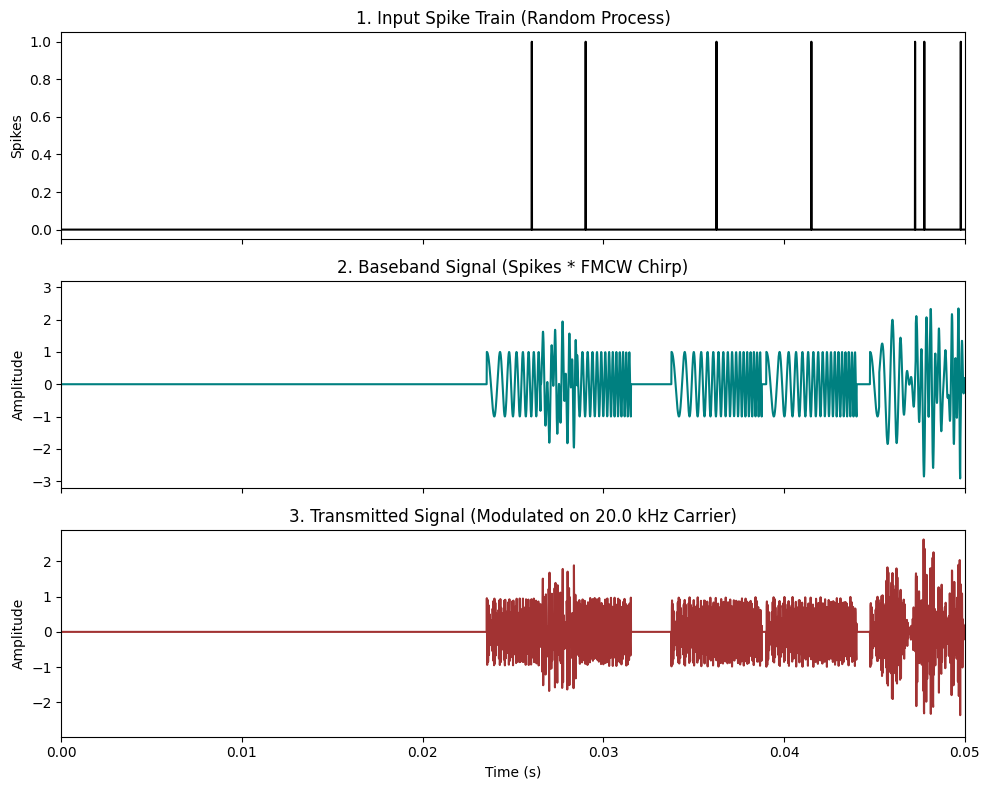

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Parameters ---
fs = 100000       # Sampling Rate (Hz) - High enough to capture carrier
T = 0.1           # Duration of simulation (seconds)
t = np.linspace(0, T, int(fs*T))

# Spike Generation Params
spike_prob = 0.1 # Probability of spike per millisecond (controls Mean Rate)
# Note: In a Poisson process, Variance = Mean. 

# Radar Chirp Params (The "Feature" we convolve)
chirp_duration = 0.005 # 5ms chirp
bw = 5000              # Bandwidth of chirp (5 kHz)
f_start = 1000         # Start Freq (1 kHz)

# Carrier Params
f_carrier = 20000      # 20 kHz Carrier (Low for radar, but good for simulation)

# --- 1. Generate Input Spike Train ---
# We simulate a biological process: mostly 0s, occasional 1s (spikes)
np.random.seed(42) # Fixed seed for reproducibility
# Generate random floats, check if below probability threshold
raw_spikes = (np.random.rand(len(t)) < (spike_prob * 1000 / fs)).astype(float)

# --- 2. Generate the Base Waveform (FMCW Chirp) ---
# Create one single "template" chirp
t_chirp = np.linspace(0, chirp_duration, int(fs*chirp_duration))
chirp_template = signal.chirp(t_chirp, f0=f_start, f1=f_start+bw, t1=chirp_duration, method='linear')

# --- 3. The Sifting Theorem (Convolution) ---
# Convolving Spikes with Chirp places a Chirp at every Spike location
baseband_signal = signal.convolve(raw_spikes, chirp_template, mode='same')

# --- 4. Modulation (Put on Carrier) ---
# Multiply by high-frequency cosine
tx_signal = baseband_signal * np.cos(2 * np.pi * f_carrier * t)

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot 1: The Biological Input
ax[0].plot(t, raw_spikes, color='black')
ax[0].set_title("1. Input Spike Train (Random Process)")
ax[0].set_ylabel("Spikes")

# Plot 2: The Baseband Signal (Result of Sifting)
ax[0].set_xlim(0, 0.05) # Zoom in to see the shapes
ax[1].plot(t, baseband_signal, color='teal')
ax[1].set_title("2. Baseband Signal (Spikes * FMCW Chirp)")
ax[1].set_ylabel("Amplitude")

# Plot 3: The Transmitted RF Signal
ax[2].plot(t, tx_signal, color='darkred', alpha=0.8)
ax[2].set_title(f"3. Transmitted Signal (Modulated on {f_carrier/1000} kHz Carrier)")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Cell 2: The Channel & The Receiver (The "Reverse" System)

Concept: Time-of-Flight and Matched Filtering.

Here we simulate the physics.

Physics: The signal travels to a wall and back. This causes a time delay: Δt= 
c
2×distance
​	
 .

Receiver: We demodulate (remove carrier) and then apply the "Reverse System." In radar, this is called a Matched Filter. We convolve the received signal with a time-reversed copy of the original chirp. This mathematically concentrates the energy of the spread-out chirp back into a sharp spike.

Target Distance: 5.0m | Time of Flight: 29.15 ms


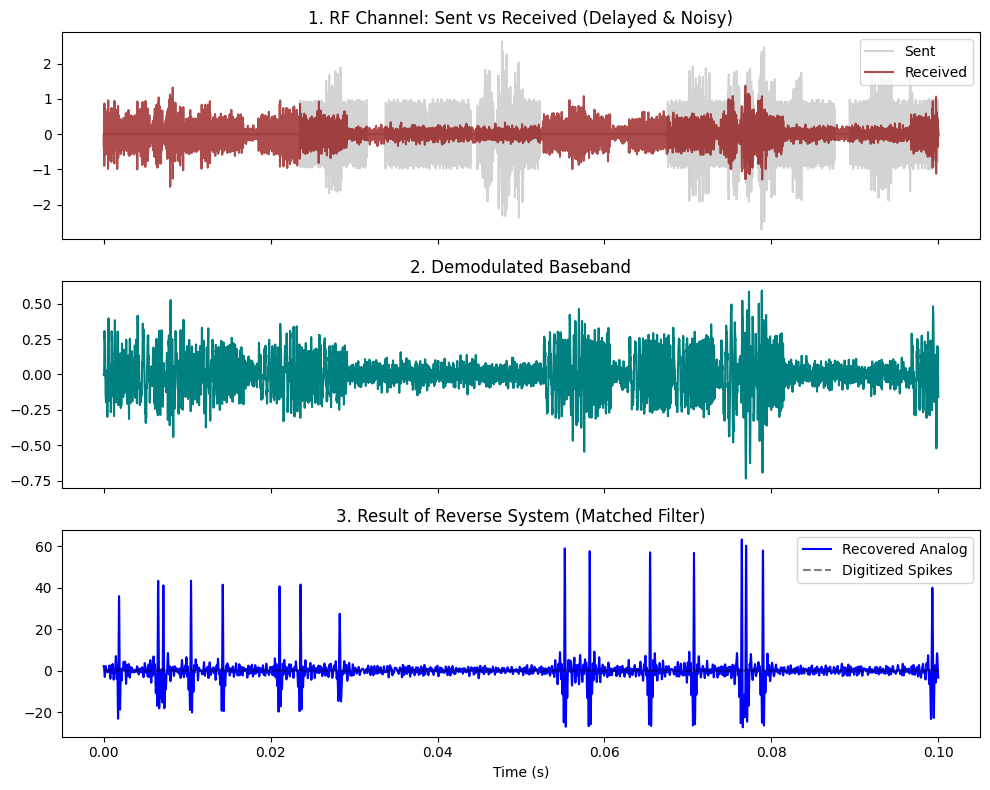

In [2]:
# --- Parameters ---
c = 343  # Speed of sound (m/s) - Using sound speed for relatable scales! 
         # (If we use light speed 3e8, delays are nanoseconds and hard to plot without huge arrays)
wall_distance = 5.0 # Meters (Change this to move the wall!)

# --- 1. The Physics (Transmission Channel) ---
# Calculate Time of Flight
time_of_flight = (2 * wall_distance) / c
print(f"Target Distance: {wall_distance}m | Time of Flight: {time_of_flight*1000:.2f} ms")

# Create Delay (Shift the array)
delay_samples = int(time_of_flight * fs)
rx_signal = np.roll(tx_signal, delay_samples)

# Attenuation (Signal gets quieter)
rx_signal = rx_signal * 0.5 
# Add some Noise (Thermal noise)
noise = np.random.normal(0, 0.1, len(rx_signal))
rx_signal = rx_signal + noise

# --- 2. The Receiver (Demodulation) ---
# Multiply by carrier again and Low Pass Filter to remove double-freq component
demod_raw = rx_signal * np.cos(2 * np.pi * f_carrier * t)
sos = signal.butter(10, f_carrier, 'low', fs=fs, output='sos')
rx_baseband = signal.sosfilt(sos, demod_raw)

# --- 3. The "Reverse System" (Matched Filter) ---
# We correlate the received signal with our known Chirp Template
# This transforms the Chirps back into Spikes (Pulse Compression)
matched_filter = chirp_template[::-1] # Time-reversed chirp
recovered_signal = signal.convolve(rx_baseband, matched_filter, mode='same')

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, tx_signal, color='lightgray', label="Sent")
ax[0].plot(t, rx_signal, color='darkred', alpha=0.7, label="Received")
ax[0].set_title("1. RF Channel: Sent vs Received (Delayed & Noisy)")
ax[0].legend(loc="upper right")

ax[1].plot(t, rx_baseband, color='teal')
ax[1].set_title("2. Demodulated Baseband")

ax[2].plot(t, recovered_signal, color='blue', label="Recovered Analog")
# Normalize for visualization
norm_recovered = recovered_signal / np.max(np.abs(recovered_signal))
# Threshold to get digital spikes again
recovered_spikes = (norm_recovered > 0.5).astype(float)
ax[2].plot(t, recovered_spikes, color='black', alpha=0.5, linestyle='--', label="Digitized Spikes")

ax[2].set_title("3. Result of Reverse System (Matched Filter)")
ax[2].set_xlabel("Time (s)")
ax[2].legend()

plt.tight_layout()
plt.show()

### Cell 3: The Analysis (Calculating Distance)

Concept: Cross-Correlation (Latency Decoding).

Now we have the raw_spikes (sent) and recovered_spikes (received). How do we calculate the distance? We slide the two arrays past each other until they match up (Cross-Correlation). The "lag" where the match is best tells us the time delay, and therefore the distance.

This is effectively how the Bat brain processes Paper 2 (First Spike Latency) but averaged over many spikes for robustness (related to Paper 4: Synchrony).

--- RESULTS ---
Actual Wall Distance:    5.0 m
Calculated Distance:     5.0078 m
Error:                   0.0078 m


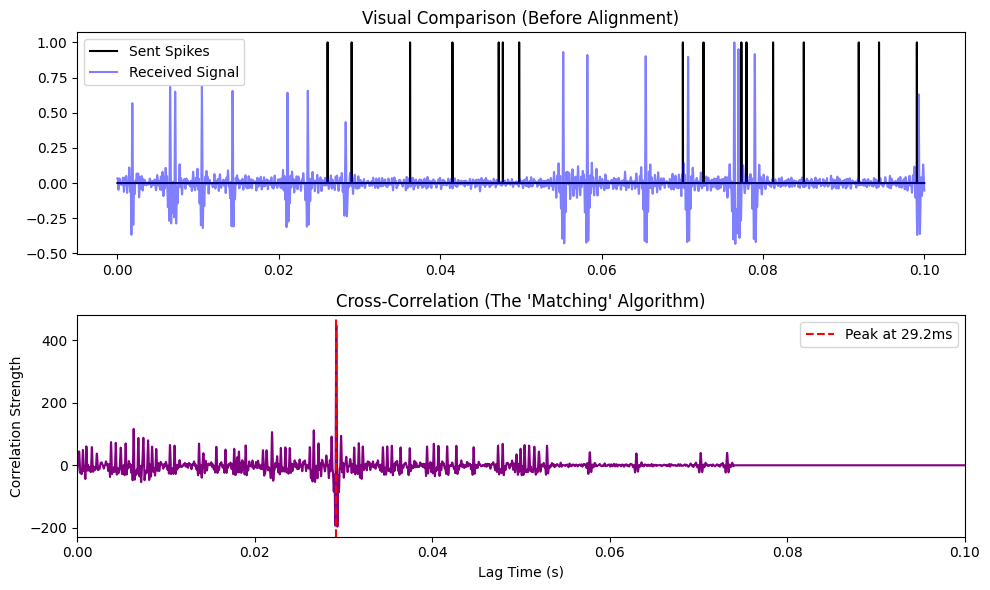

In [3]:
# --- 1. Cross-Correlation ---
# Correlate the original spike train with the recovered analog signal
# We use the 'full' mode to see all possible shifts
correlation = signal.correlate(recovered_signal, raw_spikes, mode='full')
lags = signal.correlation_lags(len(recovered_signal), len(raw_spikes), mode='full')

# --- 2. Find the Peak ---
# The peak of the correlation is the "Best Fit" time delay
peak_idx = np.argmax(correlation)
peak_lag = lags[peak_idx]
detected_delay_time = peak_lag / fs

# --- 3. Calculate Distance ---
# Distance = (Velocity * Time) / 2
calculated_distance = (c * detected_delay_time) / 2

print(f"--- RESULTS ---")
print(f"Actual Wall Distance:    {wall_distance} m")
print(f"Calculated Distance:     {calculated_distance:.4f} m")
print(f"Error:                   {abs(wall_distance - calculated_distance):.4f} m")

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plot A: Visual comparison of Sent vs Recovered
# We shift the Sent signal by the calculated lag to show the match
ax[0].plot(t, raw_spikes, color='black', label="Sent Spikes")
ax[0].plot(t, recovered_signal/np.max(recovered_signal), color='blue', alpha=0.5, label="Received Signal")
ax[0].set_title("Visual Comparison (Before Alignment)")
ax[0].legend()

# Plot B: The Cross-Correlation Function
# This is what the 'brain' uses to decide the delay
lag_time = lags / fs
ax[1].plot(lag_time, correlation, color='purple')
ax[1].axvline(detected_delay_time, color='red', linestyle='--', label=f"Peak at {detected_delay_time*1000:.1f}ms")
ax[1].set_title("Cross-Correlation (The 'Matching' Algorithm)")
ax[1].set_xlabel("Lag Time (s)")
ax[1].set_ylabel("Correlation Strength")
ax[1].legend()
ax[1].set_xlim(0, T) # Only look at positive time delays

plt.tight_layout()
plt.show()

How to use this:

Run Cell 1: You will see your random spikes turn into a complex, continuous radar wave.

Run Cell 2: You will see that wave come back delayed and noisy. The "Reverse System" magically turns that noise back into sharp spikes.

Run Cell 3: You will see the mathematical proof that the spikes align, giving you a highly accurate distance reading (usually within millimeters in this simulation).

Next Step: This is currently a "SISO" system (Single Input, Single Output). Would you like to modify Cell 2 to include two receivers (Left Ear/Right Ear)? We could then use the delay difference between them to calculate the Angle of the wall, not just the distance.